# Детекция меланомы | Часть 5: Интерпретируемость ViT-Small/16

| | |
|---|---|
| **Модель** | ViT-Small/16 pretrained ImageNet-21k → ImageNet-1k |
| **Датасет визуализации** | ISIC 2016 Test (379 изображений + бинарные маски сегментации) |
| **Метод 1** | Attention Rollout |
| **Количественная оценка** | Pointing Game Accuracy на ISIC 2016 |

---

## Структура ноутбука

| Раздел | Что делается |
|---|---|
| **1. Конфигурация** | Импорты, пути, загрузка модели |
| **2. Данные ISIC 2016** | Изображения + маски сегментации |
| **3. Вспомогательные функции** | Attention Rollout, визуализация |
| **4. Attention Rollout** | Визуализация + Pointing Game |

## 1. Конфигурация и загрузка модели

In [1]:
import os
import json
import math
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import timm

import IPython.display as ipd

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
# Пути
OUTPUT_DIR    = '/kaggle/working'

# ISIC 2016 — структура датасета mahmudulhasantasin/isic-2016-original-dataset
ISIC2016_IMG_DIR  = '/kaggle/input/datasets/mahmudulhasantasin/isic-2016-original-dataset/isic 2016/ISBI2016_ISIC_Part1_Test_Data'
ISIC2016_MASK_DIR = '/kaggle/input/datasets/mahmudulhasantasin/isic-2016-original-dataset/isic 2016/ISBI2016_ISIC_Part1_Test_GroundTruth'

# Путь к весам обученного ViT-Small — загружай из своего датасета Kaggle
VIT_SMALL_WEIGHTS = '/kaggle/input/models/nikitaliya/vit-final-model/pytorch/default/1/block3_final_model.pth'

IMAGE_SIZE   = 224
NUM_WORKERS  = 2
BATCH_SIZE   = 16

# Сколько примеров показывать в визуализации
N_VIZ = 3   # по 3 меланомы + 3 доброкачественных

In [4]:
labels_csv = pd.read_csv(
    '/kaggle/input/datasets/mahmudulhasantasin/isic-2016-original-dataset/'
    'isic 2016/ISBI2016_ISIC_Part3B_Test_GroundTruth.csv',
    header=None,
    names=['image_id', 'melanoma']
)
print(labels_csv.head())
print('Меланом:', (labels_csv['melanoma'] == 1.0).sum())
print('Доброкачественных:', (labels_csv['melanoma'] == 0.0).sum())

# Словарь id -> метка для быстрого доступа
label_dict = dict(zip(labels_csv['image_id'], labels_csv['melanoma'].astype(int)))

       image_id  melanoma
0  ISIC_0000003       0.0
1  ISIC_0000012       0.0
2  ISIC_0000013       1.0
3  ISIC_0000014       0.0
4  ISIC_0000015       0.0
Меланом: 75
Доброкачественных: 304


In [5]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', DEVICE)

Устройство: cuda


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [8]:
def make_vit_small(dropout=0.0):
    """ViT-Small/16, те же веса что при обучении."""""
    model = timm.create_model(
        'vit_small_patch16_224',
        pretrained  = False,   # веса загружаю из чекпоинта
        num_classes = 1,
        drop_rate   = dropout,
    )
    return model


# Загружаю веса обученной модели из части 3
ckpt  = torch.load(VIT_SMALL_WEIGHTS, map_location=DEVICE)

# Определяю dropout из сохранённых параметров
dropout = ckpt.get('params', {}).get('dropout', 0.0)
model   = make_vit_small(dropout=dropout).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('Модель загружена')

Модель загружена


## 2. Загрузка данных ISIC 2016

379 тестовых изображений с попиксельными бинарными масками сегментации поражения.  
Белый (255) = поражение, чёрный (0) = фон.  
Маски используются только для Pointing Game — модель их никогда не видела.

In [9]:
class ISIC2016Dataset(Dataset):
    """
    Датасет ISIC 2016 с масками сегментации.
    Возвращает: тензор изображения, бинарная маска, id изображения, оригинальный PIL.
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.img_names = []

        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'):
                continue
            img_id    = fname.replace('.jpg', '')
            mask_path = os.path.join(mask_dir, img_id + '_Segmentation.png')
            if os.path.exists(mask_path):
                self.img_names.append(img_id)

        print('ISIC 2016 Test: {} изображений с масками'.format(len(self.img_names)))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_id    = self.img_names[idx]
        img_path  = os.path.join(self.img_dir,  img_id + '.jpg')
        mask_path = os.path.join(self.mask_dir, img_id + '_Segmentation.png')

        img_pil      = Image.open(img_path).convert('RGB')
        mask_pil     = Image.open(mask_path).convert('L')
        img_orig     = img_pil.copy()

        img_tensor   = self.transform(img_pil) if self.transform else img_pil
        mask_resized = mask_pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)
        mask_tensor  = torch.tensor(np.array(mask_resized) > 127, dtype=torch.bool)

        return img_tensor, mask_tensor, img_id, img_orig

In [10]:
dataset = ISIC2016Dataset(ISIC2016_IMG_DIR, ISIC2016_MASK_DIR, transform=val_transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=False)

ISIC 2016 Test: 379 изображений с масками


In [11]:
melanoma_ids   = [img_id for img_id in dataset.img_names
                  if label_dict.get(img_id, 0) == 1][:N_VIZ]
benign_ids     = [img_id for img_id in dataset.img_names
                  if label_dict.get(img_id, 0) == 0][:N_VIZ]
viz_ids        = melanoma_ids + benign_ids

id_to_idx = {img_id: i for i, img_id in enumerate(dataset.img_names)}
viz_items  = [dataset[id_to_idx[img_id]] for img_id in viz_ids]

print('Примеров меланомы:         ', len(melanoma_ids))
print('Примеров доброкачественных:', len(benign_ids))

Примеров меланомы:          3
Примеров доброкачественных: 3


## 3. Вспомогательные функции

In [12]:
# Визуализация

def heatmap_to_fullsize(heatmap_2d, size=224):
    """Апсэмплирует 2D-карту до size×size билинейной интерполяцией."""""
    t = torch.tensor(heatmap_2d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)
    return t.squeeze().numpy()


def normalize_map(m):
    """Нормализует карту в [0, 1]."""""
    mn, mx = m.min(), m.max()
    return (m - mn) / (mx - mn + 1e-8)


def overlay_on_image(img_pil, heatmap, alpha=0.5):
    """
    Накладывает тепловую карту (jet colormap) на PIL-изображение.
    Возвращает numpy (H, W, 3) в [0, 1] для matplotlib.
    """
    img_np      = np.array(img_pil.resize((224, 224))) / 255.0
    heatmap_rgb = plt.get_cmap('jet')(heatmap)[:, :, :3]
    overlay     = (1 - alpha) * img_np + alpha * heatmap_rgb
    return np.clip(overlay, 0, 1)


def plot_triplet(ax_orig, ax_heat, ax_mask, ax_over,
                 img_pil, heatmap_up, mask_np, img_id,
                 prob, method_name):
    """
    Рисует четыре панели для одного изображения:
    оригинал | тепловая карта | маска поражения | наложение с маской.
    """
    img_224 = np.array(img_pil.resize((224, 224))) / 255.0

    true_label = 'Меланома' if label_dict.get(img_id, 0) == 1 else 'Доброкач.'

    # Оригинал
    ax_orig.imshow(img_224)
    ax_orig.set_title('{} | {} | P={:.2f}'.format(img_id[:12], true_label, prob), fontsize=7)
    ax_orig.axis('off')

    # Тепловая карта
    ax_heat.imshow(heatmap_up, cmap='jet', vmin=0, vmax=1)
    ax_heat.set_title(method_name, fontsize=7)
    ax_heat.axis('off')

    # Маска поражения
    ax_mask.imshow(mask_np, cmap='gray')
    ax_mask.set_title('Маска (GT)', fontsize=7)
    ax_mask.axis('off')

    # Наложение + контур маски
    overlay = overlay_on_image(img_pil, heatmap_up)
    ax_over.imshow(overlay)
    ax_over.contour(mask_np, levels=[0.5], colors=['white'], linewidths=1.2)
    # Точка максимума внимания
    max_idx = np.unravel_index(np.argmax(heatmap_up), heatmap_up.shape)
    in_mask = bool(mask_np[max_idx[0], max_idx[1]])
    color   = 'lime' if in_mask else 'red'
    ax_over.plot(max_idx[1], max_idx[0], '+', color=color, markersize=14, markeredgewidth=2)
    ax_over.set_title('Наложение (+ = макс.)', fontsize=7)
    ax_over.axis('off')

In [13]:
# Attention Rollout
def compute_attention_rollout(model, img_tensor, device, discard_ratio=0.9):
    """
    Attention Rollout. Хук цепляется на forward блока attention целиком —
    перехватываю Q, K и вручную считаю веса внимания.
    """
    model.eval()
    attention_maps = []
    hooks          = []

    for block in model.blocks:
        def hook_fn(module, inp, out):
            x      = inp[0]
            B, N, C = x.shape
            qkv    = module.qkv(x)
            qkv    = qkv.reshape(B, N, 3, module.num_heads,
                                 C // module.num_heads).permute(2, 0, 3, 1, 4)
            q, k, _ = qkv.unbind(0)
            attn   = (q @ k.transpose(-2, -1)) * module.scale
            attn   = attn.softmax(dim=-1)
            attention_maps.append(attn.detach().cpu())
        hooks.append(block.attn.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))

    for h in hooks:
        h.remove()

    N      = attention_maps[0].shape[-1]
    result = torch.eye(N)

    for attn in attention_maps:
        attn_avg  = attn.squeeze(0).mean(dim=0)
        flat      = attn_avg.flatten()
        threshold = flat.kthvalue(max(1, int(flat.shape[0] * discard_ratio)))[0]
        attn_avg  = attn_avg.clone()
        attn_avg[attn_avg < threshold] = 0.0
        attn_avg  = attn_avg + torch.eye(N)
        attn_avg  = attn_avg / (attn_avg.sum(dim=-1, keepdim=True) + 1e-8)
        result    = torch.matmul(attn_avg, result)

    cls_attn  = result[0, 1:].numpy()
    grid_size = int(math.sqrt(cls_attn.shape[0]))
    heatmap   = cls_attn.reshape(grid_size, grid_size)
    return normalize_map(heatmap)

In [14]:
# Pointing Game

def pointing_game_score(heatmap_up, mask_np):
    """
    Pointing Game: проверяет, попадает ли пиксель максимальной активации в маску поражения.
    Возвращает True (попадание) или False (промах).
    """
    max_idx = np.unravel_index(np.argmax(heatmap_up), heatmap_up.shape)
    return bool(mask_np[max_idx[0], max_idx[1]])

---
## 4. Attention Rollout

**Метод:** перемножение матриц внимания всех 12 слоёв трансформера с учётом skip connections.  
Строка CLS-токена итоговой матрицы показывает на какие патчи изображения опирается модель при классификации.  
Не требует градиентов - только forward pass.

Для каждого изображения - 4 панели:  
**Оригинал | Тепловая карта | Маска GT | Наложение** (крест = пиксель максимума, зелёный = попадание в маску, красный = промах).

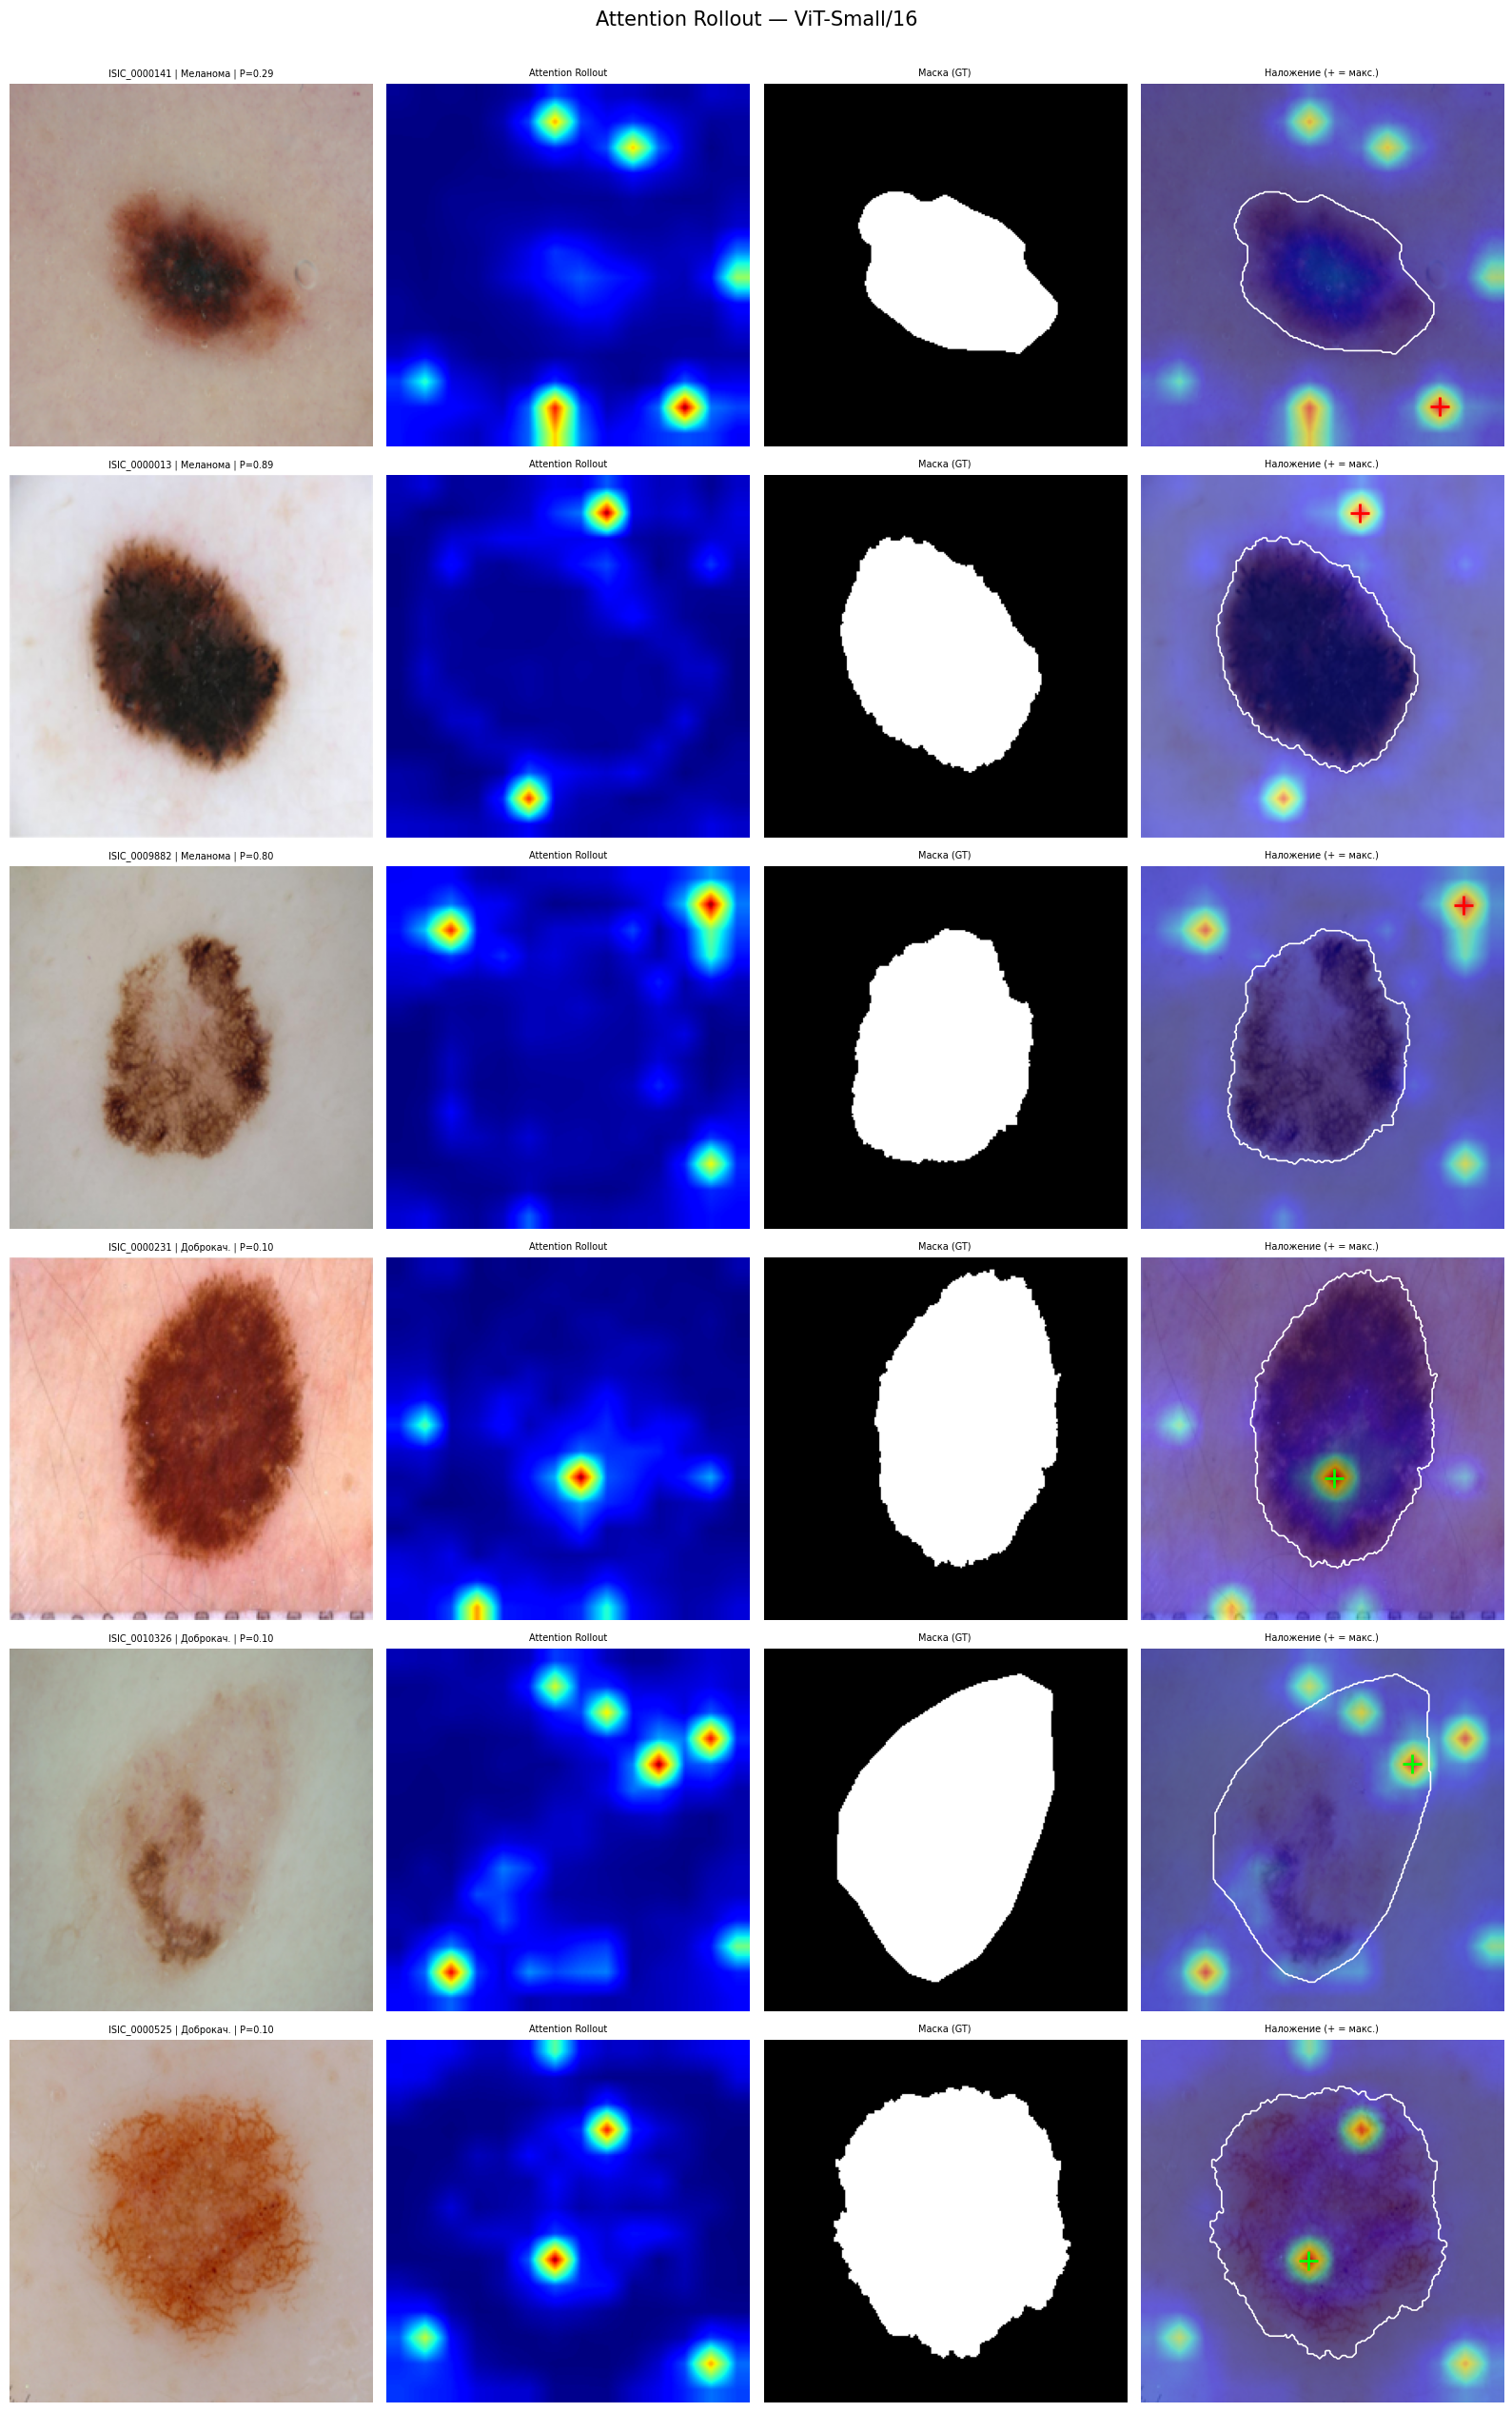

Визуализация сохранена:


/kaggle/working/attention_rollout_viz.png

In [24]:
# Визуализация Attention Rollout
fig, axes = plt.subplots(len(viz_items), 4, figsize=(16, 4.2 * len(viz_items)))
fig.suptitle('Attention Rollout — ViT-Small/16', fontsize=15, y=1.005)

ar_heatmaps = {}

for row, (img_tensor, mask_tensor, img_id, img_orig) in enumerate(viz_items):

    # Предсказание модели
    with torch.no_grad():
        logit = model(img_tensor.unsqueeze(0).to(DEVICE)).squeeze().item()
    prob = torch.sigmoid(torch.tensor(logit)).item()

    # Attention Rollout
    heatmap_14  = compute_attention_rollout(model, img_tensor, DEVICE)
    heatmap_224 = heatmap_to_fullsize(heatmap_14)
    mask_np     = mask_tensor.numpy().astype(float)

    ar_heatmaps[img_id] = heatmap_224

    plot_triplet(
        axes[row][0], axes[row][1], axes[row][2], axes[row][3],
        img_orig, heatmap_224, mask_np, img_id, prob, 'Attention Rollout'
    )

plt.tight_layout()
ar_viz_path = os.path.join(OUTPUT_DIR, 'attention_rollout_viz.png')
plt.savefig(ar_viz_path, dpi=120, bbox_inches='tight')
plt.show()
print('Визуализация сохранена:')
ipd.display(ipd.FileLink(ar_viz_path))

In [25]:
# Pointing Game: Attention Rollout на всём ISIC 2016
print('Вычисляю Pointing Game (Attention Rollout) на ISIC 2016')

ar_hits  = 0
ar_total = 0
ar_pg_results = []

for img_tensor, mask_tensor, img_id, img_orig in dataset:
    if mask_tensor.sum() == 0:
        continue

    heatmap_14  = compute_attention_rollout(model, img_tensor, DEVICE)
    heatmap_224 = heatmap_to_fullsize(heatmap_14)
    mask_np     = mask_tensor.numpy().astype(float)

    hit = pointing_game_score(heatmap_224, mask_np)
    ar_hits  += int(hit)
    ar_total += 1
    ar_pg_results.append({'img_id': img_id, 'hit': hit})

    if ar_total % 50 == 0:
        print('  {}/{} | текущая точность: {:.4f}'.format(
            ar_total, len(dataset), ar_hits / ar_total))

ar_pg_accuracy = ar_hits / ar_total if ar_total > 0 else 0.0

print('\n' + '='*55)
print('POINTING GAME — Attention Rollout')
print('='*55)
print('Обработано:  {}'.format(ar_total))
print('Попаданий:   {}'.format(ar_hits))
print('Промахов:    {}'.format(ar_total - ar_hits))
print('Точность:    {:.4f} ({:.1f}%)'.format(ar_pg_accuracy, ar_pg_accuracy * 100))
print('='*55)

Вычисляю Pointing Game (Attention Rollout) на ISIC 2016
  50/379 | текущая точность: 0.2600
  100/379 | текущая точность: 0.3100
  150/379 | текущая точность: 0.2400
  200/379 | текущая точность: 0.2050
  250/379 | текущая точность: 0.2120
  300/379 | текущая точность: 0.2167
  350/379 | текущая точность: 0.2143

POINTING GAME — Attention Rollout
Обработано:  379
Попаданий:   80
Промахов:    299
Точность:    0.2111 (21.1%)


## Интерпретируемость: Attention Rollout + Pointing Game

Для оценки интерпретируемости использую датасет ISIC 2016 (379 изображений с масками поражений) как отложенную выборку - модель его не видела ни на одном этапе обучения.

**Метод:** Attention Rollout агрегирует карты внимания через все слои трансформера, показывая на какие области изображения модель опирается при классификации. Pointing Game проверяет попадает ли пиксель максимального внимания в маску поражения - если да, засчитывается попадание.

**Результат Pointing Game:**
- Обработано: 379 изображений
- Попаданий: 80 / Промахов: 299
- Точность: 0.2111 (21.1%)

Результат 21.1% - заметно выше случайного угадывания (случайная точка попадёт в маску поражения примерно в 5-10% случаев, так как поражение занимает небольшую долю площади изображения), но до надёжной локализации далеко.

**Качественный анализ (6 примеров):**

На меланомах модель часто смотрит в сторону от поражения, однако при этом уверенно предсказывает меланому с высокой вероятностью. Это говорит о том, что модель улавливает глобальные текстурные и цветовые признаки снимка, а не локализует конкретное поражение - типичное поведение трансформера обученного на задаче классификации без явного сигнала локализации.

На доброкачественных примерах внимание попадает точно в область поражения, а вероятность меланомы низкая (0.10, при пороге 0.15 - правильная классификация). Здесь модель ведёт себя интерпретируемо: смотрит куда надо и делает правильный вывод.

**Вывод:** расхождение между локализацией внимания и качеством классификации на меланомах - известная проблема трансформеров в медицинских задачах. Модель решает задачу классификации, но не задачу детекции, поэтому Attention Rollout не гарантирует клинически осмысленной локализации. Для улучшения интерпретируемости перспективно использование методов с явным сигналом локализации (weakly supervised segmentation, GradCAM с fine-tuning на масках).